# 📰 Fake News Detection Using NLP and Machine Learning

## Fake News Detection

This project builds a machine learning system to classify news articles as
**Real** or **Fake**.

## Dataset:

Kaggle Fake News dataset containing Fake.csv and True.csv. Fake articles are labeled 0 and real articles are labeled 1.

### Objectives

- Explore and understand the news dataset
- Clean and preprocess textual data using NLP techniques
- Convert text into numerical features using TF-IDF
- Train Naive Bayes and Logistic Regression classifiers
- Compare model performance
- Evaluate models using Accuracy, Precision, Recall and F1-Score
- Analyze classification errors
- Build a final Fake/Real news prediction system

### Machine Learning Pipeline

News Dataset  
↓  
Data Cleaning  
↓  
NLP Text Preprocessing  
↓  
Train/Test Split  
↓  
TF-IDF Vectorization  
↓  
Naive Bayes / Logistic Regression  
↓  
Model Comparison  
↓  
Evaluation  
↓  
Fake / Real Prediction

# Import Libraries

In [1]:
import os
import re
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Dataset

In [2]:
# Search for CSV files inside Kaggle input directory

csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

print(f"CSV files found: {len(csv_files)}")

for file in csv_files[:30]:
    print(file)

CSV files found: 3
/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv


In [3]:
fake_path = None
true_path = None

for file in csv_files:
    filename = os.path.basename(file).lower()

    if filename == "fake.csv":
        fake_path = file

    elif filename == "true.csv":
        true_path = file

print("Fake file:", fake_path)
print("True file:", true_path)

Fake file: /kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv
True file: /kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv


In [4]:
if fake_path is None or true_path is None:
    raise FileNotFoundError(
        "Fake.csv and True.csv were not found. "
        "Check your Kaggle dataset files."
    )

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake dataset shape:", fake_df.shape)
print("True dataset shape:", true_df.shape)

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


In [5]:
fake_df = fake_df.copy()
true_df = true_df.copy()

fake_df["label"] = 0
true_df["label"] = 1

print("Fake label = 0")
print("Real label = 1")

Fake label = 0
Real label = 1


## Combine Dataset

In [6]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (44898, 5)


In [7]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [9]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [10]:
print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(44898, 5)

Columns:
['title', 'text', 'subject', 'date', 'label']

Data Types:
title      object
text       object
subject    object
date       object
label       int64
dtype: object


## Data Cleaning & Preprocessing

In [11]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [12]:
# Remove Duplicates
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal :", after)
print("Duplicates removed            :", before - after)

Rows before duplicate removal: 44898
Rows after duplicate removal : 44689
Duplicates removed            : 209


In [13]:
text_columns = ["title", "text"]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("")

df["content"] = (
    df["title"].astype(str) + " " +
    df["text"].astype(str)
)

df["content"] = df["content"].str.strip()

df = df[df["content"].str.len() > 20].copy()

print("Dataset after text cleaning:", df.shape)

Dataset after text cleaning: (44689, 6)


In [14]:
# Check Class Distribution

label_counts = df["label"].value_counts().sort_index()

print("Class distribution:")
print(label_counts)

print("\nPercentages:")
print(
    df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Class distribution:
label
0    23478
1    21211
Name: count, dtype: int64

Percentages:
label
0    52.54
1    47.46
Name: proportion, dtype: float64


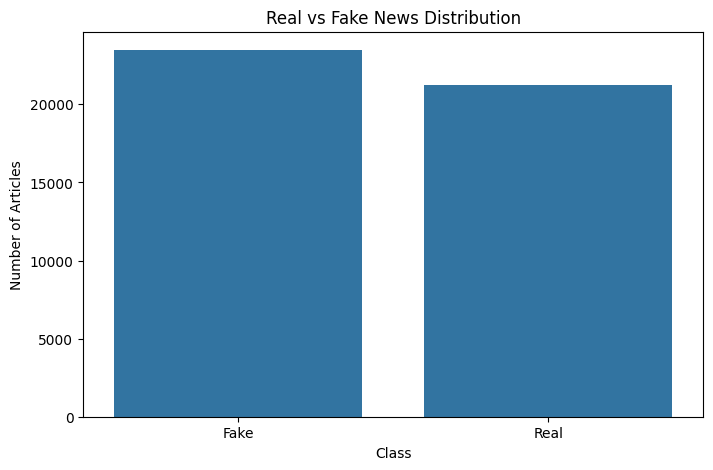

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Real vs Fake News Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Articles")

plt.xticks(
    [0, 1],
    ["Fake", "Real"]
)

plt.show()

# NLP Preprocessing

The raw news articles contain punctuation, URLs, numbers and other elements
that may introduce unnecessary noise.

The preprocessing pipeline:

1. Convert text to lowercase
2. Remove URLs
3. Remove HTML tags
4. Remove punctuation
5. Remove numbers
6. Normalize whitespace

The cleaned text will then be converted into numerical features using TF-IDF.

In [16]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


df["clean_text"] = df["content"].apply(clean_text)

df[["content", "clean_text", "label"]].head()

,content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends out embarrassing new year s...,0
1,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes an internet joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,trump is so obsessed he even has obama s name ...,0
4,Pope Francis Just Called Out Donald Trump Duri...,pope francis just called out donald trump duri...,0


In [17]:
# Check Preprocessing
for i in range(3):
    print("=" * 80)

    print("ORIGINAL:")
    print(df["content"].iloc[i][:500])

    print("\nCLEANED:")
    print(df["clean_text"].iloc[i][:500])

    print()

ORIGINAL:
Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a

CLEANED:
donald trump sends out embarrassing new year s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest fake news 

In [18]:
# Text Length Analysis
df["word_count"] = df["clean_text"].str.split().str.len()

print(df["word_count"].describe())

count    44689.000000
mean       422.729844
std        356.485052
min          0.000000
25%        217.000000
50%        380.000000
75%        532.000000
max       8295.000000
Name: word_count, dtype: float64


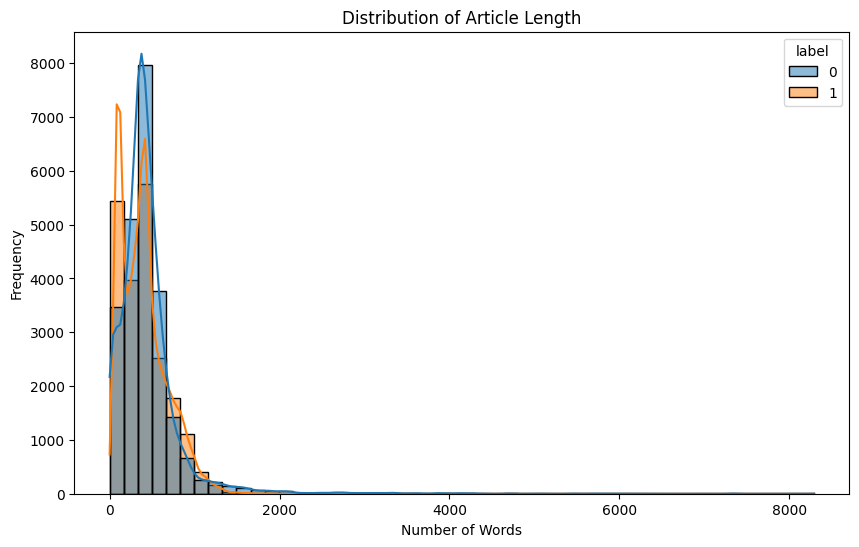

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Distribution of Article Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# Data Spliting

In [20]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 35751
Testing samples : 8938


In [21]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
label
0    0.525356
1    0.474644
Name: proportion, dtype: float64

Testing distribution:
label
0    0.525397
1    0.474603
Name: proportion, dtype: float64


# TF-IDF Vectorization

Machine learning algorithms cannot directly process raw text.

TF-IDF converts each article into a numerical vector.

The vectorizer uses:

- Unigrams: individual words
- Bigrams: two-word combinations
- Sublinear TF scaling
- Minimum document frequency filtering

TF-IDF is fitted only on the training data to prevent data leakage.

In [22]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (35751, 100000)
Testing TF-IDF shape : (8938, 100000)


In [23]:
# Inspect TF-IDF Vocabulary
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of TF-IDF features: 100000

First 30 features:
['aa' 'aaa' 'aadhaar' 'aapl' 'aaron' 'aaron bernstein' 'aaron burr'
 'aaron klein' 'aarp' 'ab' 'aba' 'abaaoud' 'ababa' 'aback' 'abad' 'abadi'
 'abadi office' 'abadi ordered' 'abadi said' 'abandon' 'abandon nuclear'
 'abandoned' 'abandoning' 'abandonment' 'abandons' 'abas' 'abas aslani'
 'abasaslani' 'abasaslani january' 'abated']


# Model 1: Naive Bayes

In [24]:
nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB(alpha=0.1)

In [25]:
nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes training completed.")

Naive Bayes training completed.


# Model 2: Logistic Regression

In [26]:
lr_model = LogisticRegression(
    max_iter=2000,
    C=2.0,
    random_state=RANDOM_STATE
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(C=2.0, max_iter=2000, random_state=42)

In [27]:
lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression training completed.")

Logistic Regression training completed.


# Model Evaluation Function

In [28]:
def evaluate_model(name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

# Compare Models

In [29]:
results = []

results.append(
    evaluate_model(
        "Multinomial Naive Bayes",
        y_test,
        nb_predictions
    )
)

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_predictions
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.964757,0.963199,0.962518,0.962858
1,Logistic Regression,0.994742,0.992949,0.995992,0.994469


In [30]:
# Display Performance
results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

results_display[metric_columns] = (
    results_display[metric_columns] * 100
).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,96.48,96.32,96.25,96.29
1,Logistic Regression,99.47,99.29,99.60,99.45


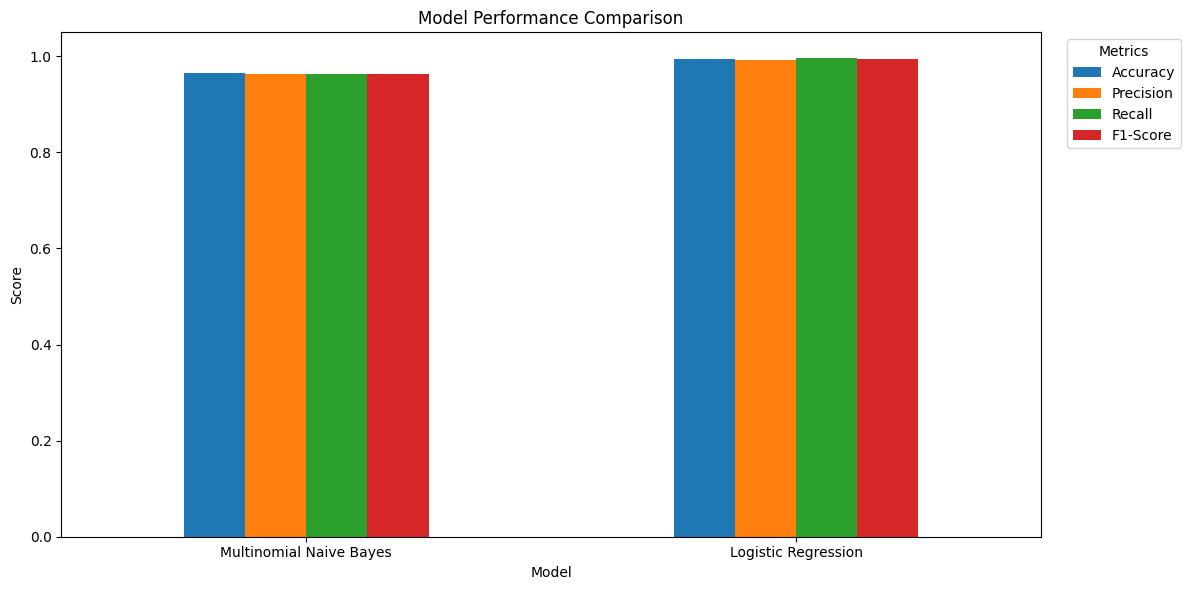

In [31]:
plot_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Select Best Model

In [32]:
best_model_name = (
    results_df
    .sort_values("F1-Score", ascending=False)
    .iloc[0]["Model"]
)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


# Final Model

In [33]:
if best_model_name == "Multinomial Naive Bayes":
    final_model = nb_model
    final_predictions = nb_predictions

else:
    final_model = lr_model
    final_predictions = lr_predictions

print("Final model:", best_model_name)

Final model: Logistic Regression


## Classification Report

In [34]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Fake", "Real"],
        digits=4
    )
)

              precision    recall  f1-score   support

        Fake     0.9964    0.9936    0.9950      4696
        Real     0.9929    0.9960    0.9945      4242

    accuracy                         0.9947      8938
   macro avg     0.9947    0.9948    0.9947      8938
weighted avg     0.9947    0.9947    0.9947      8938



In [35]:
# Final Accuracy and F1

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

print(f"Final Model: {best_model_name}")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"F1-Score: {final_f1:.4f}")

Final Model: Logistic Regression
Accuracy: 0.9947
F1-Score: 0.9945


# Confusion Matrix

In [36]:
cm = confusion_matrix(
    y_test,
    final_predictions
)

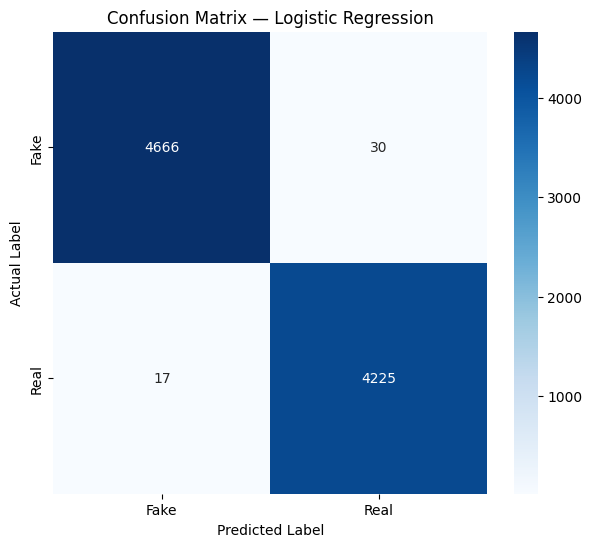

In [37]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows how many articles were correctly and incorrectly
classified.

- **True Negative:** Fake news correctly classified as Fake
- **True Positive:** Real news correctly classified as Real
- **False Positive:** Fake news incorrectly classified as Real
- **False Negative:** Real news incorrectly classified as Fake

A strong classifier should minimize both false positives and false negatives.

# Error Analysis

In [38]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": final_predictions
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Total test samples:", len(error_df))
print("Misclassified samples:", len(errors))

error_rate = len(errors) / len(error_df)

print(f"Error rate: {error_rate:.4%}")

Total test samples: 8938
Misclassified samples: 47
Error rate: 0.5258%


In [39]:
# Display Misclassified Articles

display(
    errors.head(10)
)

,text,actual,predicted
22,traffic is for the little people clinton carpe...,0,1
103,vacationing lame duck obama ready to announce ...,0,1
515,hillary clinton spars with comedian on parody ...,1,0
559,usa usa usa troops cheer president trump durin...,0,1
834,breaking trump announces phenomenal tax cut pl...,0,1
1117,north korea trump s recklessness could trigger...,0,1
1141,breaking u s supreme court justice antonin sca...,0,1
1183,breaking under trump s leadership fema could r...,0,1
1394,palestinian protesters attack us embassy in le...,0,1
1689,before the white house kennedy was a high scho...,1,0


In [40]:
# Error Analysis by Class

print("Actual class distribution among errors:")
print(
    errors["actual"]
    .map({0: "Fake", 1: "Real"})
    .value_counts()
)

print("\nPrediction distribution among errors:")
print(
    errors["predicted"]
    .map({0: "Fake", 1: "Real"})
    .value_counts()
)

Actual class distribution among errors:
actual
Fake    30
Real    17
Name: count, dtype: int64

Prediction distribution among errors:
predicted
Real    30
Fake    17
Name: count, dtype: int64


## Confidence Analysis

In [41]:
if hasattr(final_model, "predict_proba"):
    probabilities = final_model.predict_proba(X_test_tfidf)

    confidence = probabilities.max(axis=1)

    confidence_df = pd.DataFrame({
        "actual": y_test.values,
        "predicted": final_predictions,
        "confidence": confidence
    })

    confidence_df.head()

## Confidence Distribution

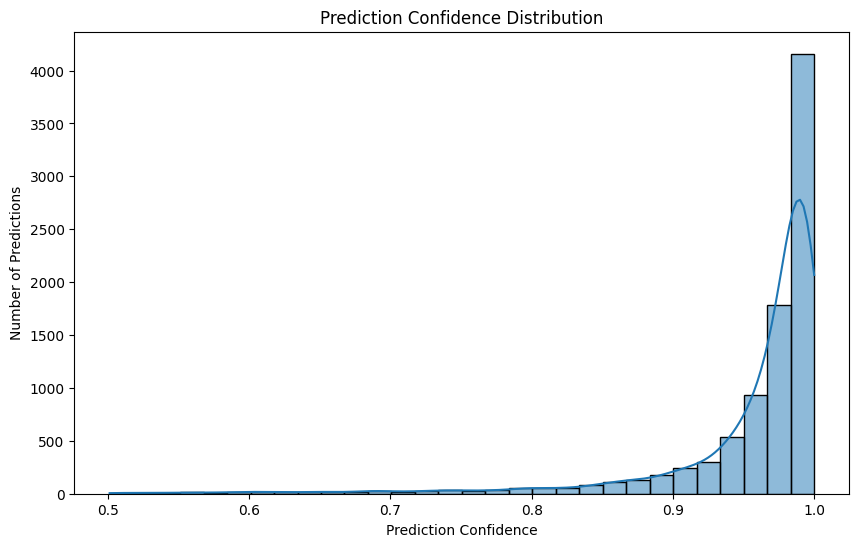

In [42]:
if "confidence_df" in globals():

    plt.figure(figsize=(10, 6))

    sns.histplot(
        confidence_df["confidence"],
        bins=30,
        kde=True
    )

    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Prediction Confidence")
    plt.ylabel("Number of Predictions")

    plt.show()

# Prediction Function

In [43]:
def predict_news(text):
    
    cleaned = clean_text(text)
    
    vectorized = tfidf.transform([cleaned])
    
    prediction = final_model.predict(vectorized)[0]
    
    if hasattr(final_model, "predict_proba"):
        probability = final_model.predict_proba(vectorized)[0]
        confidence = probability[prediction]
    else:
        confidence = None
    
    label = "REAL" if prediction == 1 else "FAKE"
    
    return label, confidence

# Test the Model

In [44]:
test_news = [
    "The government announced a new economic policy today after a cabinet meeting.",
    "Scientists discovered that eating chocolate instantly gives humans the ability to fly.",
    "The central bank announced changes to interest rates following its latest meeting.",
    "A secret technology has reportedly allowed people to live for 500 years."
]

for news in test_news:
    
    label, confidence = predict_news(news)
    
    print("=" * 80)
    print("NEWS:")
    print(news)
    print("\nPREDICTION:", label)
    
    if confidence is not None:
        print(f"CONFIDENCE: {confidence:.2%}")

NEWS:
The government announced a new economic policy today after a cabinet meeting.

PREDICTION: FAKE
CONFIDENCE: 76.87%
NEWS:
Scientists discovered that eating chocolate instantly gives humans the ability to fly.

PREDICTION: FAKE
CONFIDENCE: 88.25%
NEWS:
The central bank announced changes to interest rates following its latest meeting.

PREDICTION: REAL
CONFIDENCE: 66.43%
NEWS:
A secret technology has reportedly allowed people to live for 500 years.

PREDICTION: FAKE
CONFIDENCE: 93.75%


## Interactive Predictor

In [45]:
def check_news():
    
    print("📰 Fake News Detector")
    print("Enter a news article.")
    print("Type 'exit' to stop.\n")
    
    while True:
        
        text = input("Enter news: ").strip()
        
        if text.lower() == "exit":
            print("Exiting...")
            break
        
        if not text:
            print("Please enter some text.")
            continue
        
        label, confidence = predict_news(text)
        
        print(f"\nPrediction: {label}")
        
        if confidence is not None:
            print(f"Confidence: {confidence:.2%}")
        
        print()

In [46]:
news = """
The government announced a new economic policy today
after a cabinet meeting.
"""

label, confidence = predict_news(news)

print("Prediction:", label)
print(f"Confidence: {confidence:.2%}")

Prediction: FAKE
Confidence: 76.87%


In [47]:
# Final Model Summary

summary = {
    "Best Model": best_model_name,
    "Accuracy": final_accuracy,
    "F1-Score": final_f1,
    "Training Samples": len(X_train),
    "Testing Samples": len(X_test),
    "TF-IDF Features": X_train_tfidf.shape[1]
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Best Model,Logistic Regression
1,Accuracy,0.994742
2,F1-Score,0.994469
3,Training Samples,35751
4,Testing Samples,8938
5,TF-IDF Features,100000


# 🏁 Conclusion

This project successfully developed a machine learning system for detecting
fake and real news articles.

The workflow included:

- Dataset exploration and cleaning
- Duplicate and missing-value handling
- NLP-based text preprocessing
- TF-IDF feature extraction
- Multinomial Naive Bayes classification
- Logistic Regression classification
- Model performance comparison
- Accuracy, Precision, Recall and F1-Score evaluation
- Confusion matrix analysis
- Classification error analysis
- Real/Fake prediction on new articles

The best-performing model was selected using F1-Score and used as the final
classifier.

The project demonstrates a complete NLP classification pipeline from raw news
text to an interpretable machine learning prediction system.